# Test des trainierten Modells mit neuen Fahrzeugbewertungen

In diesem Notebook werden neue Fahrzeugbewertungen geladen, mit dem trainierten NER-Modell analysiert und anschließend mit dem gespeicherten Klassifikationsmodell einer Aspektklasse zugeordnet.

Der Ablauf umfasst Datenimport, Textaufbereitung, Merkmalsextraktion, Vorhersage und Visualisierung der Ergebnisse.


# Test neuer Daten

Dieses Notebook dient zur Anwendung des trainierten Modells auf neue Fahrzeugbewertungen.

## Schritte
- Bibliotheken importieren
- Modell laden
- Neue Daten einlesen
- Vorhersagen durchführen
- Ergebnisse auswerten

### Klassifizierung neuer Presseportal-Daten

Neue Wirtschaftsnachrichten von Presseportal werden zunächst heruntergeladen und vorverarbeitet. Anschließend werden relevante Entitäten mithilfe des trainierten NER-Modells erkannt und extrahiert.

## 1. Bibliotheken und Modelle vorbereiten

Die benötigten Bibliotheken sowie gespeicherte Modelle und Hilfsfunktionen werden geladen.


In [5]:
# Dieser Codeblock führt den folgenden Verarbeitungsschritt aus.

import pandas as pd
from spacy.training import Example
import spacy
from spacy.util import minibatch
import joblib
import requests
from bs4 import BeautifulSoup
import json
import numpy as np
import matplotlib.pyplot as plt


## 2. Trainierte Modelle laden

Das trainierte NER-Modell und das Klassifikationsmodell werden aus dem Projektordner geladen.


In [6]:
# Dieser Codeblock führt den folgenden Verarbeitungsschritt aus.
# Gespeichertes Klassifikationsmodell laden
class_names = joblib.load("../models/class_names.pkl")
# Gespeichertes Klassifikationsmodell laden
NERS = joblib.load("../models/ner_names.pkl")
# Gespeichertes Klassifikationsmodell laden
model = joblib.load("../models/car_reviews_classifier.pkl")
# Trainiertes NER-Modell laden
nlp = spacy.load("../models/my_ner_model")


## 3. Neue Bewertungsdaten abrufen

Neue Fahrzeugbewertungen werden von der Webseite geladen und aus dem HTML-Dokument extrahiert.


In [10]:
# Dieser Codeblock führt den folgenden Verarbeitungsschritt aus.

mark = ['byd-cars' ,'mg-cars', 'volkswagen-cars','bmw-cars','mercedes-benz-cars']
n = 10
urls = []
sub_urls = []
for m in mark:
    url = f"https://www.carwale.com/{m}"
    print("====>", url)
# Webseite mit den neuen Bewertungen abrufen
    page = requests.get(url)
    if page.status_code != 200:
        print("Alert " + url)
        continue
# HTML-Inhalt für die weitere Verarbeitung analysieren
    soup = BeautifulSoup(page.content, 'html.parser')
# Relevante HTML-Elemente auswählen
    cars = soup.find_all("a", class_="o-C o-os", href=True,limit=n)

    for car in cars:
        sub_urls.append(
        {
            "mark": m,
            "sub_url": f"https://www.carwale.com{car['href']}reviews/"
        })


print(sub_urls)


====> https://www.carwale.com/byd-cars
====> https://www.carwale.com/mg-cars
====> https://www.carwale.com/volkswagen-cars
====> https://www.carwale.com/bmw-cars
====> https://www.carwale.com/mercedes-benz-cars
[{'mark': 'byd-cars', 'sub_url': 'https://www.carwale.com/byd-cars/atto-3/reviews/'}, {'mark': 'byd-cars', 'sub_url': 'https://www.carwale.com/byd-cars/seal/reviews/'}, {'mark': 'byd-cars', 'sub_url': 'https://www.carwale.com/byd-cars/sealion-7/reviews/'}, {'mark': 'byd-cars', 'sub_url': 'https://www.carwale.com/byd-cars/emax-7/reviews/'}, {'mark': 'byd-cars', 'sub_url': 'https://www.carwale.com/byd-cars/atto-2/reviews/'}, {'mark': 'byd-cars', 'sub_url': 'https://www.carwale.com/byd-cars/seal-u-dm-i/reviews/'}, {'mark': 'mg-cars', 'sub_url': 'https://www.carwale.com/mg-cars/windsor-ev/reviews/'}, {'mark': 'mg-cars', 'sub_url': 'https://www.carwale.com/mg-cars/hector/reviews/'}, {'mark': 'mg-cars', 'sub_url': 'https://www.carwale.com/mg-cars/comet-ev/reviews/'}, {'mark': 'mg-cars

## 4. Neue Bewertungsdaten abrufen

Neue Fahrzeugbewertungen werden von der Webseite geladen und aus dem HTML-Dokument extrahiert.


In [11]:
# Dieser Codeblock führt den folgenden Verarbeitungsschritt aus.
news_list = []


headers = {
    "User-Agent": "Mozilla/5.0"
}
for item in sub_urls:
    mark = item["mark"]
    base_url = item["sub_url"]
    for i in range(20):
        url = f"{base_url}page/{i+1}"
# Webseite mit den neuen Bewertungen abrufen
        page = requests.get(url, headers=headers)
# HTML-Inhalt für die weitere Verarbeitung analysieren
        soup = BeautifulSoup(page.content, "html.parser")


# Relevante HTML-Elemente auswählen
        cards = soup.find_all("li", class_=lambda c: c and "oxygen-card-wrapper" in c)
        lencards=len(cards)
        print("Number of reviews:", lencards)

        for card in cards:


# Relevante HTML-Elemente auswählen
            title = card.find("a", href=lambda x: x and "/reviews/" in x)

# Relevante HTML-Elemente auswählen
            comment = card.find("div", attrs={"color": "dimGray"})


# Relevante HTML-Elemente auswählen
            stars = card.find_all(
                "svg",
                attrs={"aria-label": "rating icon"}
            )

            filled_stars = [
                star for star in stars
                if "o-k3" in star.get("class", [])
            ]
            rating = len(filled_stars)

            news_list.append({
                "Title": title.get_text(" ", strip=True) if title else "None",
                "Comment": comment.get_text(" ", strip=True) if comment else "None",
                "Rating": rating,
                "mark": mark
            })
        if lencards < 10:
            break


Number of reviews: 10
Number of reviews: 10
Number of reviews: 5
Number of reviews: 10
Number of reviews: 5
Number of reviews: 9
Number of reviews: 5
Number of reviews: 0
Number of reviews: 0
Number of reviews: 10
Number of reviews: 10
Number of reviews: 10
Number of reviews: 10
Number of reviews: 10
Number of reviews: 10
Number of reviews: 3
Number of reviews: 10
Number of reviews: 1
Number of reviews: 10
Number of reviews: 10
Number of reviews: 10
Number of reviews: 1
Number of reviews: 2
Number of reviews: 10
Number of reviews: 7
Number of reviews: 10
Number of reviews: 10
Number of reviews: 4
Number of reviews: 7
Number of reviews: 10
Number of reviews: 10
Number of reviews: 10
Number of reviews: 10
Number of reviews: 10
Number of reviews: 10
Number of reviews: 10
Number of reviews: 10
Number of reviews: 10
Number of reviews: 10
Number of reviews: 2
Number of reviews: 2
Number of reviews: 10
Number of reviews: 10
Number of reviews: 8
Number of reviews: 10
Number of reviews: 6
Numbe

## 5. Ergebnisse strukturieren

Die extrahierten Daten und Modellvorhersagen werden in einer Tabelle zusammengeführt.


In [20]:
# Dieser Codeblock führt den folgenden Verarbeitungsschritt aus.
# Daten in einem pandas-DataFrame organisieren
df = pd.DataFrame(news_list)
df

,Title,Comment,Rating,mark
0,"No sound, smooth riding, comfortable. Best 5 ...","The driving experience is awesome. No sound, ...",4,byd-cars
1,Dont Buy - After sales is awwful... you will b...,Me and my colleague bought BYD Atto 3 months a...,1,byd-cars
2,The BYD Atto 3 claims to offer a distance of 4...,The BYD Atto 3 claims to offer a distance of 4...,1,byd-cars
3,DO NOT BUY BYD CAR PLEASE READ THE COMMENTS AN...,"Worst is better word for me to use here,car pe...",1,byd-cars
4,Car is good but after service is very bad,If there’s an opportunity to provide feedback ...,1,byd-cars
...,...,...,...,...
761,"Car is ""understated elegance"" personified",Buying Experience - The Mercedes way of owning...,4,mercedes-benz-cars
762,Enjoy the ride with smooth car,"Driving this car means out of the world, no wo...",5,mercedes-benz-cars
763,Worst after sales experience.,Tyres are not at all suitable for such heavy c...,1,mercedes-benz-cars
764,Luxury car,Very nice car worth it luxury interior feels l...,5,mercedes-benz-cars


## 6. Verarbeitungsschritt

Dieser Abschnitt führt einen weiteren Schritt der Test- und Vorhersagepipeline aus.


In [21]:
# Dieser Codeblock führt den folgenden Verarbeitungsschritt aus.
doc = nlp("TITLE:\n" +df.iloc[3]["Title"] + "\n\n" +"TEXT:\n" + df.iloc[3]["Comment"])
spacy.displacy.render(doc, style='ent')


## 7. NER-Entitäten extrahieren

Die Texte werden mit dem eigenen NER-Modell analysiert. Die erkannten Entitäten dienen später als Merkmale.


In [22]:
# Dieser Codeblock führt den folgenden Verarbeitungsschritt aus.
dfs = []

for i, df_data in df.iterrows():
    doc = nlp("TITLE:\n" +df.iloc[i]["Title"] + "\n\n" +"TEXT:\n" + df.iloc[i]["Comment"])

# Daten in einem pandas-DataFrame organisieren
    df_ner = pd.DataFrame(
# Vom NER-Modell erkannte Entitäten auslesen
        [(ent.text, ent.label_) for ent in doc.ents],
        columns=["Entität", "Typ"]
    )

    dfs.append(df_ner)


## 8. NER-Entitäten extrahieren

Die Texte werden mit dem eigenen NER-Modell analysiert. Die erkannten Entitäten dienen später als Merkmale.


In [34]:
# Dieser Codeblock führt den folgenden Verarbeitungsschritt aus.
ner_count = np.zeros((len(dfs), len(NERS)), dtype=int)

for i, df1 in enumerate(dfs):
    for j, ner in enumerate(NERS):
        ner_count[i, j] = (df1["Typ"] == ner).sum()

print(ner_count)


[[0 1 0 ... 1 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 2 1 ... 0 1 0]]


## 9. NER-Entitäten extrahieren

Die Texte werden mit dem eigenen NER-Modell analysiert. Die erkannten Entitäten dienen später als Merkmale.


In [36]:
# Dieser Codeblock führt den folgenden Verarbeitungsschritt aus.
# Aspektklasse für die neuen Daten vorhersagen
pred_id = model.predict(ner_count)


## 10. Verarbeitungsschritt

Dieser Abschnitt führt einen weiteren Schritt der Test- und Vorhersagepipeline aus.


In [37]:
# Dieser Codeblock führt den folgenden Verarbeitungsschritt aus.
df["pred_id"] = [class_names[int(i)] for i in pred_id]
df


,Title,Comment,Rating,mark,pred_id,country
0,"No sound, smooth riding, comfortable. Best 5 ...","The driving experience is awesome. No sound, ...",4,byd-cars,comfort,China
1,Dont Buy - After sales is awwful... you will b...,Me and my colleague bought BYD Atto 3 months a...,1,byd-cars,service,China
2,The BYD Atto 3 claims to offer a distance of 4...,The BYD Atto 3 claims to offer a distance of 4...,1,byd-cars,battery-fuel consumption,China
3,DO NOT BUY BYD CAR PLEASE READ THE COMMENTS AN...,"Worst is better word for me to use here,car pe...",1,byd-cars,service,China
4,Car is good but after service is very bad,If there’s an opportunity to provide feedback ...,1,byd-cars,service,China
...,...,...,...,...,...,...
761,"Car is ""understated elegance"" personified",Buying Experience - The Mercedes way of owning...,4,mercedes-benz-cars,service,Deutschland
762,Enjoy the ride with smooth car,"Driving this car means out of the world, no wo...",5,mercedes-benz-cars,performance-quality,Deutschland
763,Worst after sales experience.,Tyres are not at all suitable for such heavy c...,1,mercedes-benz-cars,service,Deutschland
764,Luxury car,Very nice car worth it luxury interior feels l...,5,mercedes-benz-cars,service,Deutschland


## 13. Ergebnisse visualisieren

Die vorhergesagten Aspekte und Bewertungen werden grafisch dargestellt und miteinander verglichen.


['performance-quality', 'comfort', 'service', 'battery-fuel consumption', 'price', 'safety', 'design-features']
[ 89 143 213  76 133  40  72]


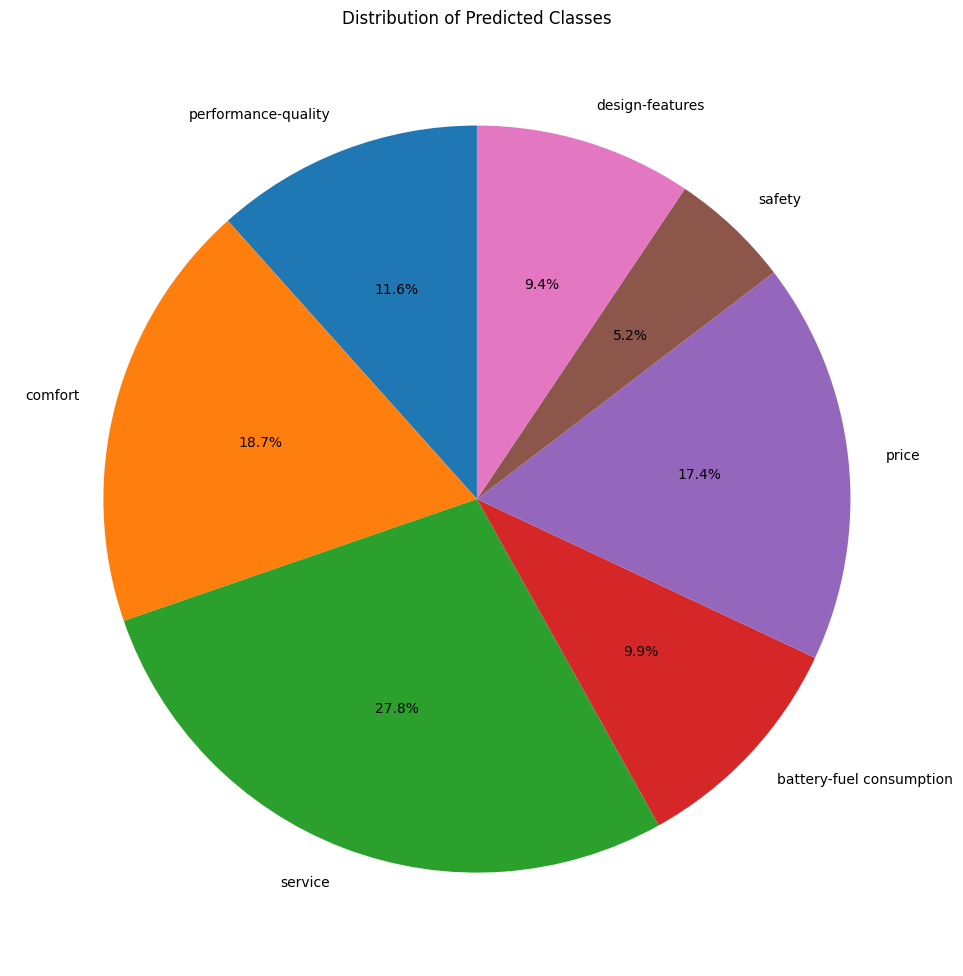

In [28]:
# Dieser Codeblock führt den folgenden Verarbeitungsschritt aus.
unique_ids, counts = np.unique(pred_id, return_counts=True)

predicted_class_names = [
    class_names[int(i)]
    for i in unique_ids
]

print(predicted_class_names)
print(counts)


# Neue Abbildung für die Visualisierung erstellen
plt.figure(figsize=(10, 10))

plt.pie(
    counts,
    labels=predicted_class_names,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Predicted Classes")
plt.tight_layout()
plt.show()


## 14. Ergebnisse visualisieren

Die vorhergesagten Aspekte und Bewertungen werden grafisch dargestellt und miteinander verglichen.


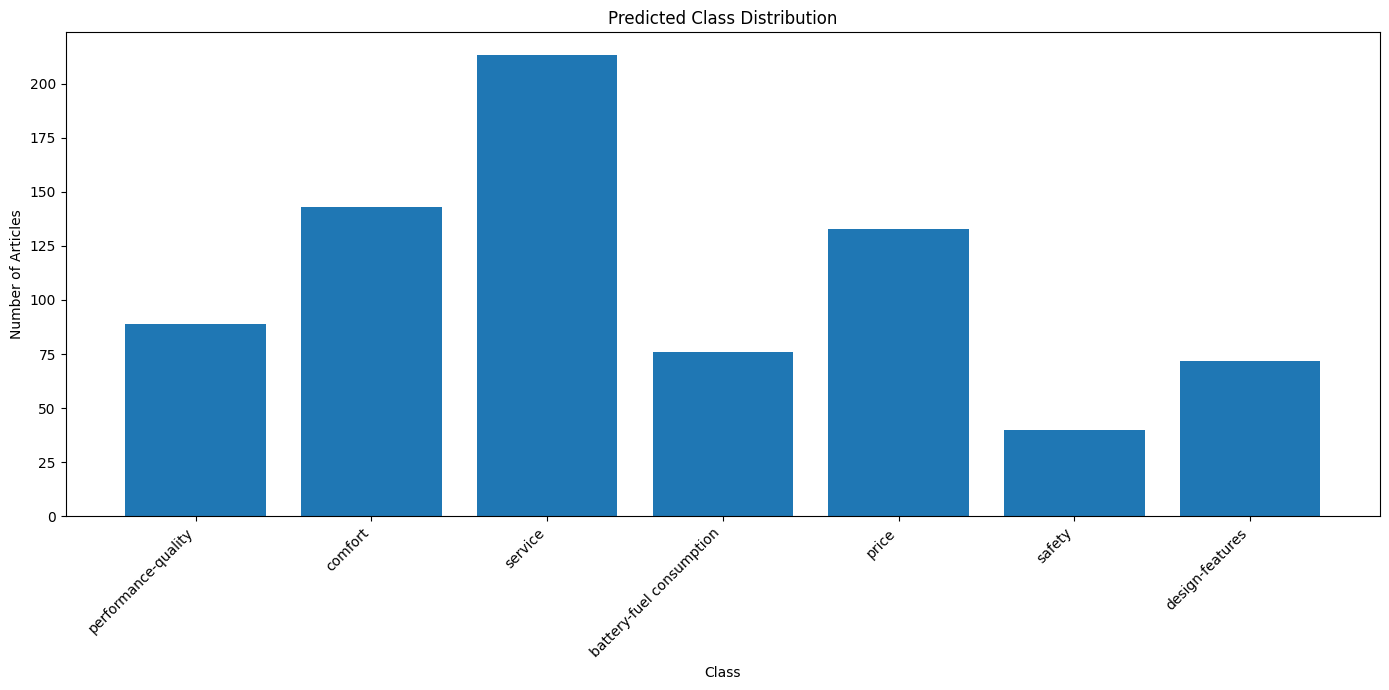

In [29]:
# Dieser Codeblock führt den folgenden Verarbeitungsschritt aus.
# Neue Abbildung für die Visualisierung erstellen
plt.figure(figsize=(14, 7))

# Ergebnisse als Diagramm darstellen
plt.bar(
    predicted_class_names,
    counts
)

plt.xlabel("Class")
plt.ylabel("Number of Articles")
plt.title("Predicted Class Distribution")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


## 15. Ergebnisse visualisieren

Die vorhergesagten Aspekte und Bewertungen werden grafisch dargestellt und miteinander verglichen.


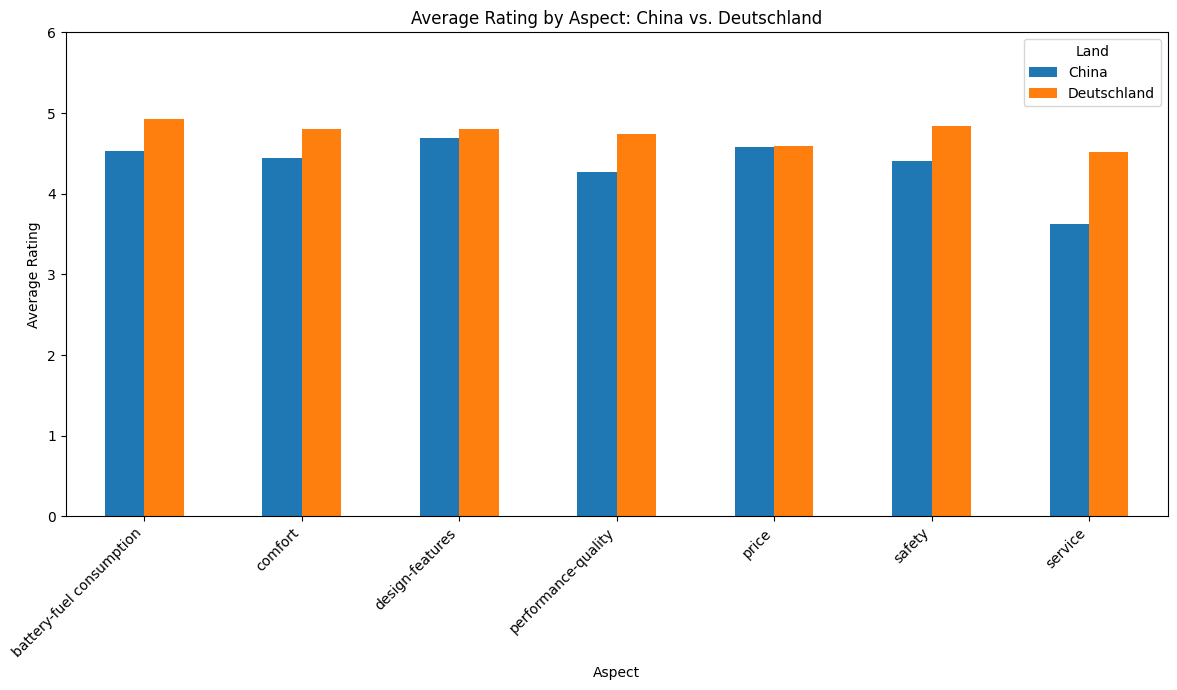

In [33]:
# Zuordnung: Marke -> Land
country_map = {
    "byd-cars": "China",
    "mg-cars": "China",
    "volkswagen-cars": "Deutschland",
    "bmw-cars": "Deutschland",
    "mercedes-benz-cars": "Deutschland"
}

# Neue Spalte für das Land erstellen
df["country"] = df["mark"].map(country_map)

# Nur die ausgewählten Marken verwenden
brands = [
    "byd-cars",
    "mg-cars",
    "volkswagen-cars",
    "bmw-cars",
    "mercedes-benz-cars"
]

plot_df = (
    df[df["mark"].isin(brands)]
    .groupby(["pred_id", "country"])["Rating"]
    .mean()
    .unstack()
)

# Balkendiagramm erstellen
plot_df.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Average Rating by Aspect: China vs. Deutschland")
plt.xlabel("Aspect")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 6)
plt.legend(title="Land")
plt.tight_layout()
plt.show()